## Data retrieval

In [5]:
import sys
from pathlib import Path
import importlib 

sys.path.append(str(Path.cwd().parent))

import src.data_retrieval 
importlib.reload(src.data_retrieval)

df_metric = src.data_retrieval.get_nasdaq_data(qopts_per_page = 10000)

if df_metric is not None:
    print("\nSuccessfully created DataFrame!")
    display(df_metric.head())
else:
    print("\nFailed to create DataFrame.")

API Key loaded successfully.
fetching data from https://data.nasdaq.com/api/v3/datatables/MER/F1.json with parameters : {'api_key': 'HsFQF5fPTGQ4um39gRhH', 'qopts.per_page': 10000}

Successfully created DataFrame!


,compnumber,reportid,mapcode,amount,reportdate,reporttype,auditorstatus,currency,consolidated,longname,...,city,statecode,country,zipcode,phonenumber,faxnumber,website,fye,indicator,statement
0,2438,1868192544,-1802,10.481948,2011-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
1,2438,1868216112,-1802,8.161754,2011-09-30,Q3,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
2,2438,1885063456,-1802,10.788213,2012-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
3,2438,1885087024,-1802,9.437545,2012-09-30,Q3,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
4,2438,1901934112,-1802,8.755041,2013-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived


## Data exploration and understanding

In [11]:
print("DataFrame shape :", df_metric.shape)
print(df_metric.info())

DataFrame shape : (10000, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   compnumber     10000 non-null  int64  
 1   reportid       10000 non-null  int64  
 2   mapcode        10000 non-null  int64  
 3   amount         10000 non-null  float64
 4   reportdate     10000 non-null  object 
 5   reporttype     10000 non-null  object 
 6   auditorstatus  9999 non-null   object 
 7   currency       10000 non-null  object 
 8   consolidated   10000 non-null  object 
 9   longname       10000 non-null  object 
 10  shortname      10000 non-null  object 
 11  status         10000 non-null  object 
 12  countrycode    10000 non-null  object 
 13  region         10000 non-null  object 
 14  cik            10000 non-null  int64  
 15  mic            10000 non-null  object 
 16  ticker         9380 non-null   object 
 17  exchange       10000 

### Identifying necessary columns

Based on the `.info()` output and our project goals, we need to answer two questions:
1.  Trend Analysis: What is the 'Accrued Expenses Turnover' for various companies over time?
2.  Comparative Analysis: How do these metrics compare across different regions?

To do this my chosen columns are:
- `indicator`: To filter the DataFrame down to *only* the 'Accrued Expenses Turnover' metric.
- `amount`: The actual numerical value of the metric.
- `reportdate`: The date, which is essential for any trend analysis over time.
- `longname`: The name of the company (e.g., 'Deutsche Bank AG').
- `country`: For the regional analysis.
- `region`: For a higher-level regional analysis.

In [12]:
necessary_columns = [
    'indicator', 
    'amount', 
    'reportdate', 
    'longname', 
    'country', 
    'region'
    ]

## Data filtering and intial analysis

### Filtering for "Accrued Expenses Turnover"

My full dataset (`df_metric`) contains 10,000 rows, but this includes many different financial indicators. For this analysis, I am only interested in the **'Accrued Expenses Turnover'**.

My next step is to create a new, clean DataFrame that:
1.  Contains *only* the columns I selected in my `necessary_columns` list.
2.  Contains *only* the rows where the `indicator` is 'Accrued Expenses Turnover'.


In [14]:
df_analysis_subset = df_metric[necessary_columns].copy()
filtered_df = df_analysis_subset[
    df_analysis_subset['indicator'] == 'Accrued Expenses Turnover'
].copy()
print(f"Original DataFrame shape: {df_metric.shape}")
print(f"New Filtered DataFrame shape: {filtered_df.shape}")
display(filtered_df)

Original DataFrame shape: (10000, 32)
New Filtered DataFrame shape: (139, 6)


,indicator,amount,reportdate,longname,country,region
0,Accrued Expenses Turnover,10.481948,2011-06-30,Deutsche Bank AG,DEU,Europe
1,Accrued Expenses Turnover,8.161754,2011-09-30,Deutsche Bank AG,DEU,Europe
2,Accrued Expenses Turnover,10.788213,2012-06-30,Deutsche Bank AG,DEU,Europe
3,Accrued Expenses Turnover,9.437545,2012-09-30,Deutsche Bank AG,DEU,Europe
4,Accrued Expenses Turnover,8.755041,2013-06-30,Deutsche Bank AG,DEU,Europe
...,...,...,...,...,...,...
8454,Accrued Expenses Turnover,96.208696,2011-12-31,Nielsen Holdings PLC,USA,Europe
8685,Accrued Expenses Turnover,111.933333,2012-12-31,Nielsen Holdings PLC,USA,Europe
8920,Accrued Expenses Turnover,122.645161,2013-12-31,Nielsen Holdings PLC,USA,Europe
9153,Accrued Expenses Turnover,147.952941,2014-12-31,Nielsen Holdings PLC,USA,Europe


In [16]:
display(filtered_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 139 entries, 0 to 9386
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   indicator   139 non-null    object 
 1   amount      139 non-null    float64
 2   reportdate  139 non-null    object 
 3   longname    139 non-null    object 
 4   country     139 non-null    object 
 5   region      139 non-null    object 
dtypes: float64(1), object(5)
memory usage: 7.6+ KB


None

In [17]:
display(filtered_df.describe())

,amount
count,139.000000
mean,26.908762
std,33.097291
min,4.689773
25%,9.675670
50%,13.753753
75%,31.777614
max,229.810427


## 5. Data Cleaning

After filtering, I inspected the resulting DataFrame and discovered a significant data integrity issue.

* **Finding:** Several companies, such as 'Nielsen Holdings PLC', were listed with `country` as 'USA' but `region` as 'Europe'.
* **Hypothesis:** This is likely due to the company having headquarters in Europe, while its primary operations and stock listing are in the USA.
* **Decision:** The `region` column is unreliable for our regional analysis. I will drop it and use the more accurate `country_code` column instead.

I will also perform other cleaning steps, like converting the `reportdate` column from a string to a proper `datetime` object, which is essential for our time-series analysis. This logic will be saved in a `clean_turnover_data` function in the `src/analysis.py` module.

In [19]:
from src.analysis import clean_turnover_data
importlib.reload(src.analysis)
cleaned_df = clean_turnover_data(filtered_df)
print("DataFrame cleaned successfully.")
display(cleaned_df.head())
cleaned_df.info()

DataFrame cleaned successfully.


,indicator,amount,reportdate,company_name,country_code,country_name
0,Accrued Expenses Turnover,10.481948,2011-06-30,Deutsche Bank AG,DEU,Germany
1,Accrued Expenses Turnover,8.161754,2011-09-30,Deutsche Bank AG,DEU,Germany
2,Accrued Expenses Turnover,10.788213,2012-06-30,Deutsche Bank AG,DEU,Germany
3,Accrued Expenses Turnover,9.437545,2012-09-30,Deutsche Bank AG,DEU,Germany
4,Accrued Expenses Turnover,8.755041,2013-06-30,Deutsche Bank AG,DEU,Germany


<class 'pandas.core.frame.DataFrame'>
Index: 139 entries, 0 to 9386
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   indicator     139 non-null    object        
 1   amount        139 non-null    float64       
 2   reportdate    139 non-null    datetime64[ns]
 3   company_name  139 non-null    object        
 4   country_code  139 non-null    object        
 5   country_name  139 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 7.6+ KB


### Country Frequency Analysis

Now that I have a clean `country_name` column, I will use `.value_counts()` to see the distribution of data points across countries. This helps me understand which countries have the most data and which are under-represented.

In [20]:
country_counts = cleaned_df['country_name'].value_counts()
print("Frequency of data points by country:")
display(country_counts)

Frequency of data points by country:


country_name
United States     31
Japan             27
Cayman Islands    27
Ireland           25
Bahamas           19
Germany            6
Other              4
Name: count, dtype: int64

**Analysis of Country Counts:**

The output of `.value_counts()` shows that `United States`, `Japan`, `Cayman Islands`, `Ireland` account for the vast majority of the data. The `Other` category is significantly less in number, which means I do not need to expand my `country_mapping` dictionary if I want to analyze those countries individually.

## Time-Series Trend Analysis (2010-2015)

### Analysis Goal: Visualizing Trends from 2010-2015

Now that I have a clean dataset (`cleaned_df`), I can focus on one of our primary goals: **analyzing financial trends over time.**

To do this, I will:
1.  **Filter by Time:** Narrow the dataset to a specific, relevant period (2010-2015).
2.  **Select Columns:** Create a new DataFrame with only the columns needed for this plot: `company_name`, `reportdate`, and `amount`.
3.  **Visualize:** Plot each company's 'Accrued Expenses Turnover' on a single line chart to compare their performance over this period.

In [ ]:
start_date = '2010-01-01'
end_date = '2015-12-31'
time_filtered_df = cleaned_df[
    (cleaned_df['reportdate'] >= start_date) & 
    (cleaned_df['reportdate'] <= end_date)
].copy()
relevant_columns = ['company_name', 'reportdate', 'amount']
relevant_data = time_filtered_df[relevant_columns]
print(f"Filtered data for plotting. New shape: {relevant_data.shape}")
display(relevant_data.head())

Filtered data for plotting. New shape: (139, 3)


,company_name,reportdate,amount
0,Deutsche Bank AG,2011-06-30,10.481948
1,Deutsche Bank AG,2011-09-30,8.161754
2,Deutsche Bank AG,2012-06-30,10.788213
3,Deutsche Bank AG,2012-09-30,9.437545
4,Deutsche Bank AG,2013-06-30,8.755041


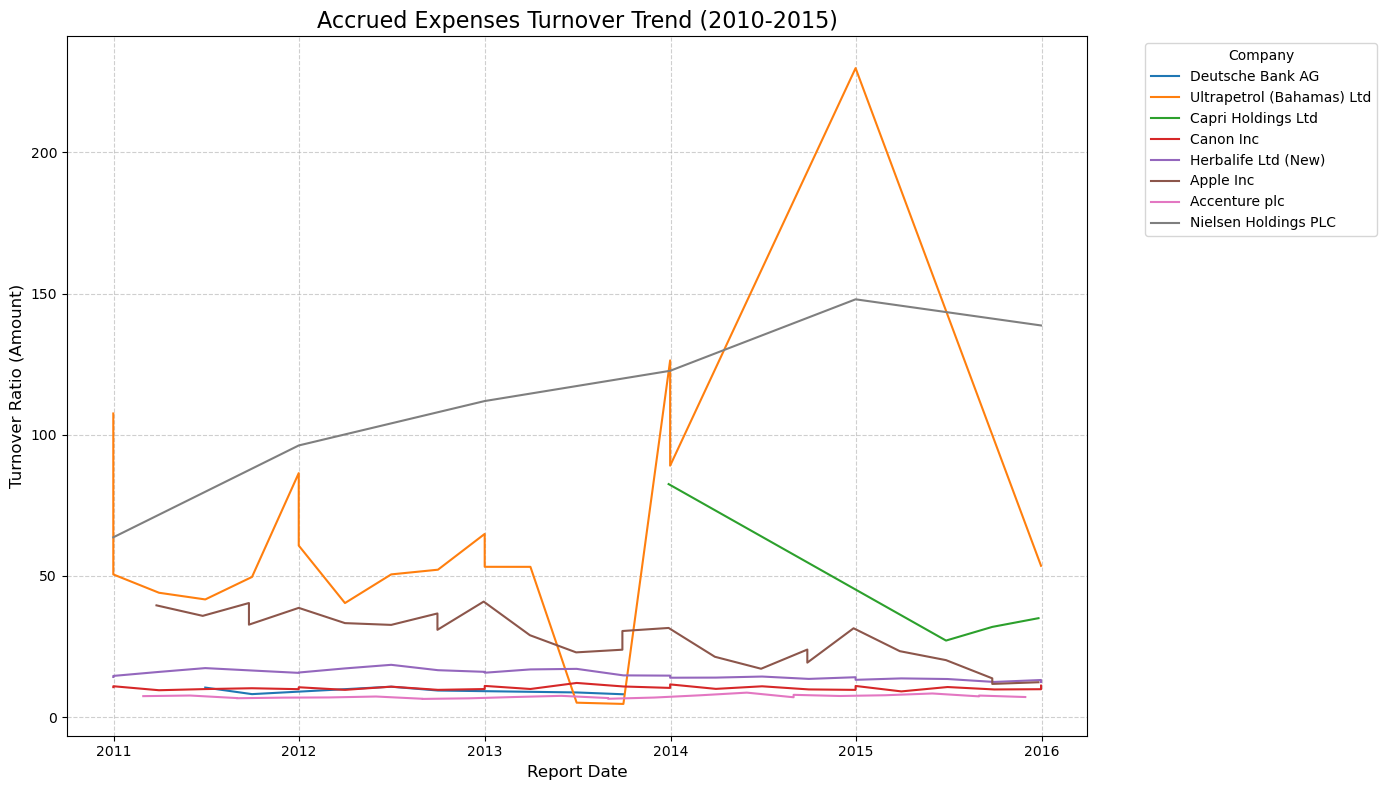

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 8))
companies = relevant_data['company_name'].unique()
for company in companies:
    company_data = relevant_data[relevant_data['company_name'] == company]
    company_data = company_data.sort_values(by='reportdate')
    plt.plot(
        company_data['reportdate'],  
        company_data['amount'],        
        label=company                
    )
plt.title('Accrued Expenses Turnover Trend (2010-2015)', fontsize=16)
plt.xlabel('Report Date', fontsize=12)
plt.ylabel('Turnover Ratio (Amount)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(
    title='Company',
    bbox_to_anchor=(1.05, 1), 
    loc='upper left'           
)
plt.tight_layout() 
plt.show()

### 6. Time-Series Trend Analysis (2010-2015)

The combined time-series plot above immediately reveals a significant challenge: the dataset contains **extreme outliers** that make a direct comparison impossible.

* **Key Finding:** The turnover ratios for **`Ultrapetrol (Bahamas) Ltd`** (peaking over 200) and **`Nielsen Holdings PLC`** (peaking around 150) are on a completely different scale from the other companies.
* **The Problem:** These outliers "squash" the y-axis, compressing the trend lines for all other companies (like `Canon Inc` and `Accenture plc`) into a flat, unreadable band at the bottom of the chart.
* **Conclusion:** To perform a meaningful analysis, I must treat the outliers as a separate group and create a new plot focusing on the "core" group of companies.

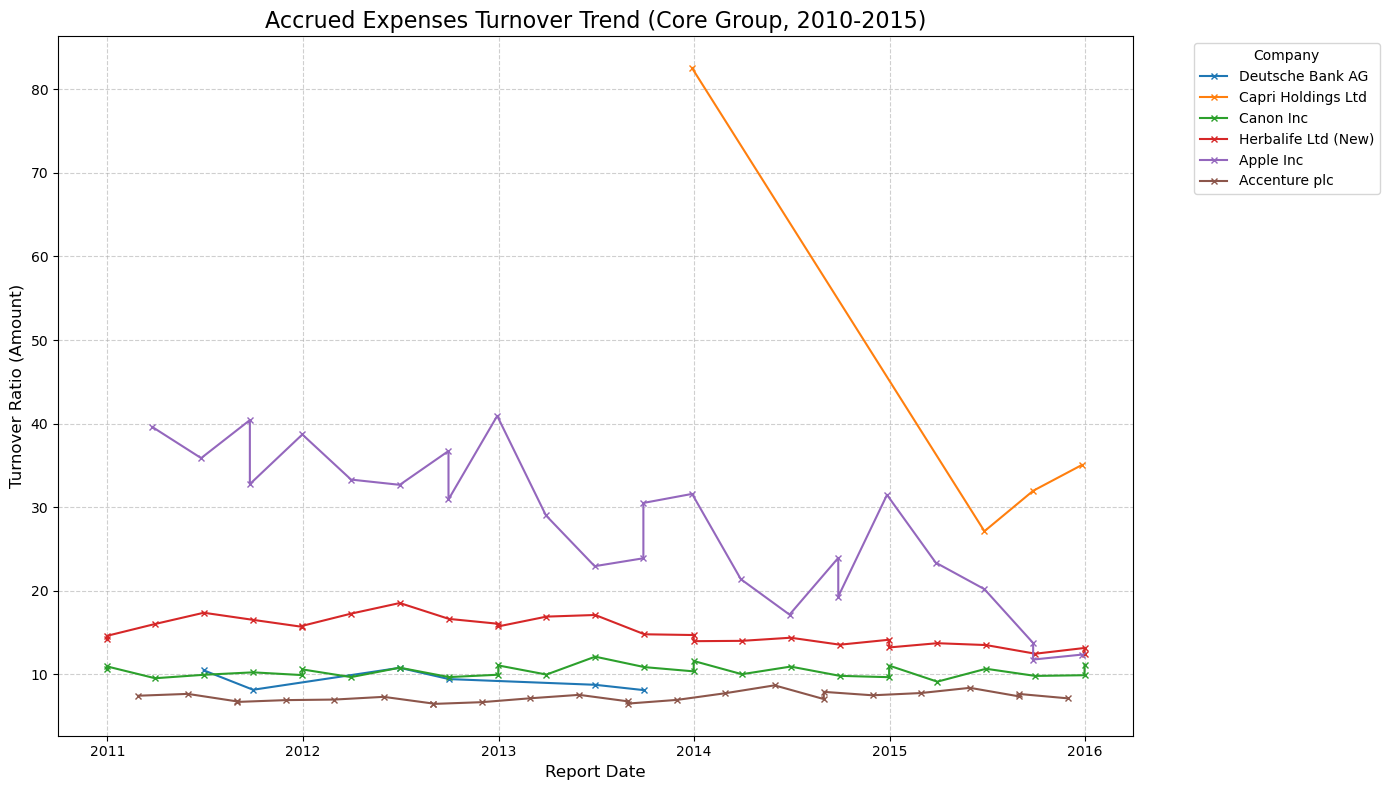

In [29]:
outliers = ['Ultrapetrol (Bahamas) Ltd', 'Nielsen Holdings PLC']
core_data = relevant_data[~relevant_data['company_name'].isin(outliers)]
plt.figure(figsize=(14, 8))
for company in core_data['company_name'].unique():
    company_data = core_data[core_data['company_name'] == company]
    company_data = company_data.sort_values(by='reportdate')
    plt.plot(
        company_data['reportdate'],  
        company_data['amount'],        
        label=company,
        marker='x',
        markersize=4
    )
plt.title('Accrued Expenses Turnover Trend (Core Group, 2010-2015)', fontsize=16)
plt.xlabel('Report Date', fontsize=12)
plt.ylabel('Turnover Ratio (Amount)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Analysis of "Core Group" Trends

This new plot is much clearer. By removing the two extreme outliers (`Ultrapetrol` and `Nielsen`), the y-axis has rescaled, and we can now accurately compare the trends of the remaining companies.

* **Clear downward trends:**
    * **`Apple Inc`** (purple line) shows a significant downward trend, starting with a turnover ratio around 40 in 2011 and declining to around 12 by 2016.
    * **`Capri Holdings Ltd`** (orange line) also shows a steep decline, though its data is sparser, dropping from a peak above 80 to around 30.

* **Stable:**
    * **`Accenture plc`** (brown line) and **`Canon Inc`** (green line) shows some volatility, but their ratios remain relatively stable.
* **Sparse data:**
    * **`Deutsche Bank AG`** (blue line) has very few data points in this period, making it difficult to analyze its trend.

**Conclusion:** This time-series analysis shows that the core companies have vastly different financial profiles. This completes the first goal of our analysis (analyzing trends over time).

The next step is to address our second goal: **examining the comparative financial metrics by country.**

## Geographical Region Analysis

### Analysis Goal: Comparing Average Turnover by Country

I will now address the second project goal: **examining the comparative financial metrics by country.**

To do this, I will:
1.  Group my `cleaned_df` by the `country_name` column.
2.  Calculate the `mean()` (average) `amount` for each country.
3.  Visualize these averages using a bar chart to easily compare them.

In [30]:
country_avg = cleaned_df.groupby('country_name')['amount'].mean().sort_values(ascending=False)
print("Average Accrued Expenses Turnover by Country:")
display(country_avg)

Average Accrued Expenses Turnover by Country:


country_name
Bahamas           66.515369
United States     44.377585
Other             44.166750
Cayman Islands    15.060796
Japan             10.376605
Germany            9.288999
Ireland            7.264400
Name: amount, dtype: float64

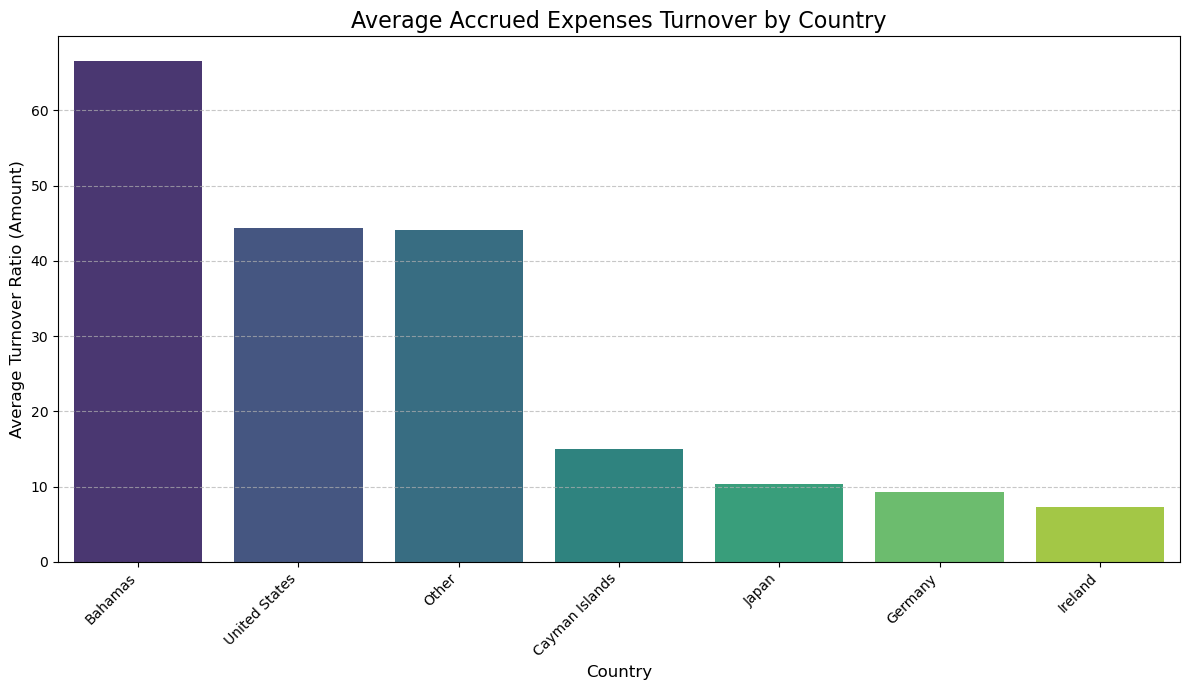

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
sns.barplot(
    x=country_avg.index, 
    y=country_avg.values,
    palette='viridis',
    hue=country_avg.index,
    legend=False
)
plt.title('Average Accrued Expenses Turnover by Country', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Average Turnover Ratio (Amount)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Analysis of Geographical Averages

This bar chart clearly visualizes the average 'Accrued Expenses Turnover' by country and confirms the findings from our time-series analysis.

* **Outlier Impact:** The **`Bahamas`** and **`United States`** show the highest average turnover ratios. This is expected and is driven by the outlier companies we identified earlier (`Ultrapetrol` and `Nielsen`), which pull up the average for their respective countries.
* **Core Group:** The remaining countries (`Cayman Islands`, `Japan`, `Germany`, `Ireland`) are all clustered at the bottom with much lower average turnover ratios (all under 20).
* **"Other" Category:** The "Other" category has a high average (around 45), which indicates that one or more of the unmapped companies are also outliers.

This plot successfully completes our second project goal: to compare financial metrics across different regions.

---
## Project Conclusion & Future Work

This project successfully demonstrated a full data analysis pipeline, starting from raw API data retrieval and performing exploratory data analysis and visualization.

### Key Findings:

1.  **Data Quality is Critical:** The raw data contained significant challenges that had to be addressed.
    * **Outliers:** The dataset included extreme outliers (like `Ultrapetrol (Bahamas) Ltd` and `Nielsen Holdings PLC`). Their turnover ratios were on a completely different scale, which skewed the time-series and geographical plots.
    * **Data Integrity:** The `region` column was found to be unreliable (e.g., 'USA' country, 'Europe' region). We resolved this by dropping the `region` column and using the more accurate `country_code` for our analysis.

2.  **Time-Series Analysis:** By separating the outliers from the "core" group, we uncovered two distinct stories:
    * **Core Group:** Showed varied trends. `Apple Inc` and `Herbalife Ltd` had clear downward trends, while `Accenture plc` and `Canon Inc` were volatile but stable within a narrow range.
    * **Outlier Group:** Showed massive volatility and a different financial scale, suggesting their business model or reporting is fundamentally different.

3.  **Geographical Analysis:** The average turnover by country is heavily skewed by the outliers. The `Bahamas` and `United States` show the highest averages, which is a direct result of `Ultrapetrol` and `Nielsen` being in those groups.

### Future Work:

This analysis could be extended in several ways:

* **Expand Metrics:** Analyze other financial metrics from the `MER/F1` table (like `Operating Margin` or `Cash Flow Per Share`) to build a more complete financial profile of these companies.
* **Handle Outliers:** Implement statistical methods to either remove outliers or analyze them as a separate statistical group.
* **Expand Country Mapping:** Enlarge the `country_mapping` dictionary to analyze the companies currently grouped under "Other".
* **Industry Comparison:** Add data on each company's industry/sector to see if these financial trends are common across a specific sector.